# Q4 — Algebraic Reconstruction Technique (ART)
Implement myART and show RRMSE vs iterations for various step-lengths.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from skimage.transform import radon

In [2]:
import h5py
def load_mat_h5_gt(path):
    try:
        with h5py.File(path,'r') as f:
            names = list(f.keys())
            for candidate in ['gt','img','I','image','phantom','X']:
                if candidate in f:
                    return np.squeeze(np.array(f[candidate])).astype(float)
            if len(names)>0:
                return np.squeeze(np.array(f[names[0]])).astype(float)
    except Exception:
        from scipy.io import loadmat
        data = loadmat(path)
        keys = [k for k in data.keys() if not k.startswith('__')]
        return np.squeeze(data[keys[0]]).astype(float)
gt = load_mat_h5_gt('data/assignmentMathImagingRecon_chestCT.mat')

In [3]:
from scipy.interpolate import RegularGridInterpolator

def precompute_rays(img_shape, t_vals, theta, ds=1.0):
    H, W = img_shape
    max_len = np.sqrt(H**2 + W**2)
    s = np.arange(-max_len, max_len, ds)
    rays = []
    for j, th_deg in enumerate(theta):
        th = np.deg2rad(th_deg)
        cos_t, sin_t = np.cos(th), np.sin(th)
        for i, t in enumerate(t_vals):
            x0 = t * cos_t; y0 = t * sin_t
            xs = x0 - s * sin_t; ys = y0 + s * cos_t
            ix = xs + (W - 1) / 2.0; iy = ys + (H - 1) / 2.0
            x0i = np.floor(ix).astype(int); y0i = np.floor(iy).astype(int)
            dx = ix - x0i; dy = iy - y0i
            valid = (x0i >= 0) & (y0i >= 0) & (x0i < W - 1) & (y0i < H - 1)
            if not np.any(valid):
                rays.append({'inds': np.array([], dtype=int), 'weights': np.array([], dtype=float), 't_idx': i, 'theta_idx': j})
                continue
            x0v = x0i[valid]; y0v = y0i[valid]; dxv = dx[valid]; dyv = dy[valid]
            w00 = (1 - dxv) * (1 - dyv); w01 = dxv * (1 - dyv)
            w10 = (1 - dxv) * dyv; w11 = dxv * dyv
            inds00 = np.ravel_multi_index((y0v, x0v), dims=(H, W))
            inds01 = np.ravel_multi_index((y0v, x0v + 1), dims=(H, W))
            inds10 = np.ravel_multi_index((y0v + 1, x0v), dims=(H, W))
            inds11 = np.ravel_multi_index((y0v + 1, x0v + 1), dims=(H, W))
            inds = np.concatenate([inds00, inds01, inds10, inds11])
            weights = np.concatenate([w00, w01, w10, w11]) * ds
            rays.append({'inds': inds, 'weights': weights, 't_idx': i, 'theta_idx': j})
    return rays


def forward_project_from_rays(img_flat, rays):
    proj = np.zeros((len(rays),), dtype=float)
    for k, r in enumerate(rays):
        if r['inds'].size == 0:
            continue
        proj[k] = img_flat[r['inds']].dot(r['weights'])
    return proj


In [4]:
def myART(meas, t_vals, theta, img_shape, iterations=10, lam=0.5, ds=1.0, ordering='sequential', init_img=None, rays=None):
    if rays is None:
        rays = precompute_rays(img_shape, t_vals, theta, ds)
    n_rays = len(rays)
    img = np.zeros(img_shape, dtype=float) if init_img is None else init_img.copy()
    img_flat = img.ravel()
    ray_idx = np.arange(n_rays)
    for it in range(iterations):
        if ordering == 'random':
            np.random.shuffle(ray_idx)
        for k in ray_idx:
            r = rays[k]
            if r['inds'].size == 0:
                continue
            inds = r['inds']
            weights = r['weights']
            p_hat = img_flat[inds].dot(weights)
            mval = meas[r['t_idx'], r['theta_idx']]
            resid = mval - p_hat
            denom = np.sum(weights * weights) + 1e-12
            alpha = lam * resid / denom
            img_flat[inds] += alpha * weights
    return img_flat.reshape(img_shape)


c:\Users\rishi\Python\Python3119\Lib\site-packages\skimage\transform\radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(
lambdas: 100%|██████████| 3/3 [00:45<00:00, 15.18s/it]


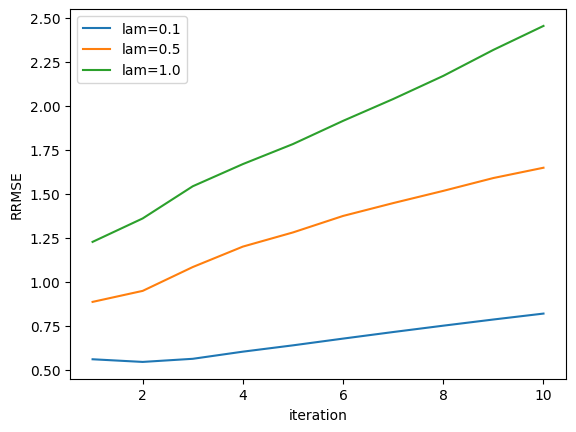

In [5]:
# prepare angles and noisy measurements
theta = np.arange(0,180,1)
t_vals = np.linspace(-int(gt.shape[0]/2), int(gt.shape[0]/2), gt.shape[0])
meas = radon(gt, theta=theta, circle=True)
noise_sigma = 0.05 * (meas.max()-meas.min())
noisy = meas + np.random.randn(*meas.shape) * noise_sigma
iterations = 10
# precompute rays once to reuse across all runs
precomp = precompute_rays(gt.shape, t_vals, theta, ds=1.0)
# progress helpers: try tqdm, else fallback to identity
try:
    from tqdm import trange, tqdm
except Exception:
    def trange(x, **kw):
        return range(x)
    def tqdm(it, **kw):
        return it
rrmse_records = {}
for lam in tqdm([0.1, 0.5, 1.0], desc='lambdas'):
    img = np.zeros_like(gt)
    errs = []
    for it in trange(iterations, desc=f'lam={lam} it'):
        img = myART(noisy, t_vals, theta, gt.shape, iterations=1, lam=lam, ds=1.0, init_img=img, rays=precomp)
        err = np.linalg.norm(gt-img)/np.linalg.norm(gt)
        errs.append(err)
    rrmse_records[lam] = errs
# plot results
for lam,errs in rrmse_records.items():
    plt.plot(np.arange(1,iterations+1), errs, label=f'lam={lam}')
plt.xlabel('iteration'); plt.ylabel('RRMSE'); plt.legend()
